In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import json
import sys

model_paths = [
    "/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/7",
    "",
]

for p in model_paths:
    if Path(p).exists():
        sys.path.insert(0, p)
        break

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))


/home/jupyter/project/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

out_dir = work_dir / "results_exp_9_helmholtz1d_large_lbfgs"
out_dir.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("work_dir:", work_dir)
print("out_dir:", out_dir)


torch version: 2.0.1+cu118
cuda available: True
gpu: Tesla V100-PCIE-32GB
device: cuda
work_dir: .
out_dir: results_exp_9_helmholtz1d_large_lbfgs


In [3]:
m_values = [8, 12]
dtype_values = ["fp32", "fp64"]
seed_values = [0]

variants = [
    {
        "variant": "resample_proven_128",
        "adam_steps": 10000,
        "lbfgs_steps": 1000,
        "lr_adam": 5e-4,
        "lbfgs_max_iter": 1,
        "lbfgs_max_eval": None,
        "lbfgs_lr": 1.0,
        "lbfgs_history_size": 50,
        "lbfgs_tolerance_grad": 1e-8,
        "lbfgs_tolerance_change": 1e-9,
        "lbfgs_line_search_fn": "strong_wolfe",
        "resample_every": 200,
        "point_mode": None,
        "n_collocation": 5000,
        "hid_size": 128,
        "num_layers": 4,
        "init_gain": None,
        "bc_weight": 1.0,
        "hard_bc": False,
    },
    {
        "variant": "resample_wide_256",
        "adam_steps": 8000,
        "lbfgs_steps": 1000,
        "lr_adam": 5e-4,
        "lbfgs_max_iter": 3,
        "lbfgs_max_eval": None,
        "lbfgs_lr": 1.0,
        "lbfgs_history_size": 50,
        "lbfgs_tolerance_grad": 1e-8,
        "lbfgs_tolerance_change": 1e-9,
        "lbfgs_line_search_fn": "strong_wolfe",
        "resample_every": 200,
        "point_mode": None,
        "n_collocation": 5000,
        "hid_size": 256,
        "num_layers": 3,
        "init_gain": 1.0,
        "bc_weight": 1.0,
        "hard_bc": False,
    },
]

runs = []
i = 1
for m in m_values:
    for variant in variants:
        for dtype in dtype_values:
            for seed in seed_values:
                row = variant.copy()
                row["run_id"] = i
                row["m"] = m
                row["dtype"] = dtype
                row["seed"] = seed
                runs.append(row)
                i += 1

pd.DataFrame(runs)


,variant,adam_steps,lbfgs_steps,lr_adam,lbfgs_max_iter,lbfgs_max_eval,lbfgs_lr,lbfgs_history_size,lbfgs_tolerance_grad,lbfgs_tolerance_change,lbfgs_line_search_fn,resample_every,point_mode,n_collocation,hid_size,num_layers,init_gain,bc_weight,hard_bc,run_id,m,dtype,seed
0,resample_proven_128,10000,1000,0.0005,1,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,128,4,NaN,1.0,False,1,8,fp32,0
1,resample_proven_128,10000,1000,0.0005,1,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,128,4,NaN,1.0,False,2,8,fp64,0
2,resample_wide_256,8000,1000,0.0005,3,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,256,3,1.0,1.0,False,3,8,fp32,0
3,resample_wide_256,8000,1000,0.0005,3,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,256,3,1.0,1.0,False,4,8,fp64,0
4,resample_proven_128,10000,1000,0.0005,1,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,128,4,NaN,1.0,False,5,12,fp32,0
5,resample_proven_128,10000,1000,0.0005,1,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,128,4,NaN,1.0,False,6,12,fp64,0
6,resample_wide_256,8000,1000,0.0005,3,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,256,3,1.0,1.0,False,7,12,fp32,0
7,resample_wide_256,8000,1000,0.0005,3,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,200,None,5000,256,3,1.0,1.0,False,8,12,fp64,0


In [4]:
base_config = {
    "task_name": "helmholtz1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "m": 8,
    "lambda_val": 1.0,
    "hid_size": 128,
    "num_layers": 4,
    "init_gain": None,
    "n_collocation": 5000,
    "point_mode": None,
    "n_bc": 2,
    "adam_steps": 10000,
    "lbfgs_steps": 1000,
    "lr_adam": 5e-4,
    "resample_every": 200,
    "use_adam": True,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-8,
    "lbfgs_tolerance_change": 1e-9,
    "lbfgs_history_size": 50,
    "lbfgs_lr": 1.0,
    "lbfgs_max_iter": 1,
    "lbfgs_max_eval": None,
    "lbfgs_line_search_fn": "strong_wolfe",
    "hard_bc": False,
    "bc_weight": 1.0,
    "log_dir": str(out_dir / "runs" / "helmholtz_large_lbfgs_tmp"),
}

pd.DataFrame(runs).groupby(["m", "variant", "dtype"]).size()


m   variant              dtype
8   resample_proven_128  fp32     1
                         fp64     1
    resample_wide_256    fp32     1
                         fp64     1
12  resample_proven_128  fp32     1
                         fp64     1
    resample_wide_256    fp32     1
                         fp64     1
dtype: int64

In [5]:
all_summaries = []
all_histories = {}

for run in runs:
    config = base_config.copy()
    config.update(run)
    config["use_adam"] = config["adam_steps"] > 0
    config["use_lbfgs"] = config["lbfgs_steps"] > 0
    name = f"exp9_r{run['run_id']:03d}_m{run['m']}_{run['variant']}_{run['dtype']}_s{run['seed']}"
    config["log_dir"] = str(out_dir / "runs" / name)

    run_dir = Path(config["log_dir"])
    summary_file = run_dir / "summary.json"
    metrics_file = run_dir / "metrics.csv"

    if summary_file.exists() and metrics_file.exists():
        with open(summary_file) as f:
            summary = json.load(f)
        history = pd.read_csv(metrics_file)
    else:
        history, summary = pinn_model.run_experiment(config)

    best = history.loc[history["l2_error"].idxmin()]
    summary["run_id"] = run["run_id"]
    summary["variant"] = run["variant"]
    summary["m"] = run["m"]
    summary["seed"] = run["seed"]
    summary["adam_steps_config"] = run["adam_steps"]
    summary["lr_adam"] = run["lr_adam"]
    summary["lbfgs_steps_config"] = run["lbfgs_steps"]
    summary["lbfgs_max_iter"] = run["lbfgs_max_iter"]
    summary["lbfgs_max_eval"] = run["lbfgs_max_eval"]
    summary["lbfgs_history_size"] = run["lbfgs_history_size"]
    summary["lbfgs_tolerance_grad"] = run["lbfgs_tolerance_grad"]
    summary["lbfgs_tolerance_change"] = run["lbfgs_tolerance_change"]
    summary["resample_every"] = run["resample_every"]
    summary["point_mode"] = run["point_mode"]
    summary["lbfgs_lr"] = run["lbfgs_lr"]
    summary["n_collocation"] = run["n_collocation"]
    summary["hid_size"] = run["hid_size"]
    summary["num_layers"] = run["num_layers"]
    summary["init_gain"] = run["init_gain"]
    summary["hard_bc"] = run["hard_bc"]
    summary["bc_weight"] = run["bc_weight"]
    summary["best_l2_error"] = float(best["l2_error"])
    summary["best_step"] = int(best["step"])
    summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])

    all_summaries.append(summary)
    all_histories[name] = history

    print(run["run_id"], run["variant"], "m", run["m"], run["dtype"], "seed", run["seed"], "final", summary["final_l2_error"], "best", summary["best_l2_error"], "time", summary["time_sec"])


1 resample_proven_128 m 8 fp32 seed 0 final 0.0022322519216686487 best 0.0022322519216686487 time 127.70034313201904
2 resample_proven_128 m 8 fp64 seed 0 final 0.0010758262542644114 best 0.0010758262542644114 time 128.07416677474976
3 resample_wide_256 m 8 fp32 seed 0 final 0.23730650544166565 best 0.23730650544166565 time 122.66413736343384
4 resample_wide_256 m 8 fp64 seed 0 final 2.205890885713629 best 0.9991073065903948 time 147.1932294368744
5 resample_proven_128 m 12 fp32 seed 0 final 0.01866859942674637 best 0.01866859942674637 time 139.69180274009705
6 resample_proven_128 m 12 fp64 seed 0 final 0.003084684244547737 best 0.003084684244547737 time 139.5144064426422
7 resample_wide_256 m 12 fp32 seed 0 final 1.0000007152557373 best 0.9996394515037537 time 196.79501867294312
8 resample_wide_256 m 12 fp64 seed 0 final 1.0000014776554678 best 0.9992590815203 time 101.71176409721375


In [6]:
df = pd.DataFrame(all_summaries)
cols = [
    "run_id", "variant", "task_name", "m", "dtype", "seed",
    "hid_size", "num_layers", "init_gain", "n_collocation", "point_mode",
    "adam_steps_config", "lr_adam", "lbfgs_steps_config", "lbfgs_max_iter", "lbfgs_max_eval",
    "lbfgs_history_size", "lbfgs_tolerance_grad", "lbfgs_tolerance_change",
    "resample_every", "lbfgs_lr", "hard_bc", "bc_weight",
    "final_loss", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "time_sec", "log_dir",
]
df = df[cols]
df.to_csv(out_dir / "exp_9_helmholtz1d_large_lbfgs_summary.csv", index=False)
df.sort_values("best_l2_error")


,run_id,variant,task_name,m,dtype,seed,hid_size,num_layers,init_gain,n_collocation,point_mode,adam_steps_config,lr_adam,lbfgs_steps_config,lbfgs_max_iter,lbfgs_max_eval,lbfgs_history_size,lbfgs_tolerance_grad,lbfgs_tolerance_change,resample_every,lbfgs_lr,hard_bc,bc_weight,final_loss,final_l2_error,best_l2_error,best_step,l2_ratio,time_sec,log_dir
1,2,resample_proven_128,helmholtz1d,8,fp64,0,128,4,NaN,5000,None,10000,0.0005,1000,1,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,1.742692e-06,0.001076,0.001076,10300,1.000000,128.074167,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
0,1,resample_proven_128,helmholtz1d,8,fp32,0,128,4,NaN,5000,None,10000,0.0005,1000,1,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,9.212951e-07,0.002232,0.002232,10200,1.000000,127.700343,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
5,6,resample_proven_128,helmholtz1d,12,fp64,0,128,4,NaN,5000,None,10000,0.0005,1000,1,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,2.030533e-06,0.003085,0.003085,11000,1.000000,139.514406,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
4,5,resample_proven_128,helmholtz1d,12,fp32,0,128,4,NaN,5000,None,10000,0.0005,1000,1,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,1.377695e-06,0.018669,0.018669,11000,1.000000,139.691803,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
2,3,resample_wide_256,helmholtz1d,8,fp32,0,256,3,1.0,5000,None,8000,0.0005,1000,3,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,9.372237e-04,0.237307,0.237307,9000,1.000000,122.664137,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
3,4,resample_wide_256,helmholtz1d,8,fp64,0,256,3,1.0,5000,None,8000,0.0005,1000,3,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,1.332994e-01,2.205891,0.999107,4600,2.207862,147.193229,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
7,8,resample_wide_256,helmholtz1d,12,fp64,0,256,3,1.0,5000,None,8000,0.0005,1000,3,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,5.021591e-01,1.000001,0.999259,4700,1.000743,101.711764,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
6,7,resample_wide_256,helmholtz1d,12,fp32,0,256,3,1.0,5000,None,8000,0.0005,1000,3,None,50,1.000000e-08,1.000000e-09,200,1.0,False,1.0,5.016689e-01,1.000001,0.999639,2600,1.000361,196.795019,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...


In [7]:
grouped = df.groupby(["variant", "m", "dtype"]).agg(
    best_l2_median=("best_l2_error", "median"),
    best_l2_min=("best_l2_error", "min"),
    final_l2_median=("final_l2_error", "median"),
    ok_1e_2=("best_l2_error", lambda x: float((x < 1e-2).mean())),
    ok_5e_2=("best_l2_error", lambda x: float((x < 5e-2).mean())),
    time_median=("time_sec", "median"),
).reset_index()

grouped.to_csv(out_dir / "exp_9_helmholtz1d_large_lbfgs_grouped.csv", index=False)
grouped.sort_values(["m", "best_l2_median"])


,variant,m,dtype,best_l2_median,best_l2_min,final_l2_median,ok_1e_2,ok_5e_2,time_median
1,resample_proven_128,8,fp64,0.001076,0.001076,0.001076,1.0,1.0,128.074167
0,resample_proven_128,8,fp32,0.002232,0.002232,0.002232,1.0,1.0,127.700343
4,resample_wide_256,8,fp32,0.237307,0.237307,0.237307,0.0,0.0,122.664137
5,resample_wide_256,8,fp64,0.999107,0.999107,2.205891,0.0,0.0,147.193229
3,resample_proven_128,12,fp64,0.003085,0.003085,0.003085,1.0,1.0,139.514406
2,resample_proven_128,12,fp32,0.018669,0.018669,0.018669,0.0,1.0,139.691803
7,resample_wide_256,12,fp64,0.999259,0.999259,1.000001,0.0,0.0,101.711764
6,resample_wide_256,12,fp32,0.999639,0.999639,1.000001,0.0,0.0,196.795019


In [8]:
best_pivot = grouped.pivot_table(
    index=["variant", "m"],
    columns="dtype",
    values="best_l2_median",
    aggfunc="first",
).reset_index()

best_pivot["fp64_over_fp32"] = best_pivot["fp64"] / best_pivot["fp32"]
best_pivot.to_csv(out_dir / "exp_9_helmholtz1d_large_lbfgs_fp64_ratio.csv", index=False)
best_pivot.sort_values("fp64_over_fp32")


dtype,variant,m,fp32,fp64,fp64_over_fp32
1,resample_proven_128,12,0.018669,0.003085,0.165234
0,resample_proven_128,8,0.002232,0.001076,0.481947
3,resample_wide_256,12,0.999639,0.999259,0.999619
2,resample_wide_256,8,0.237307,0.999107,4.210198


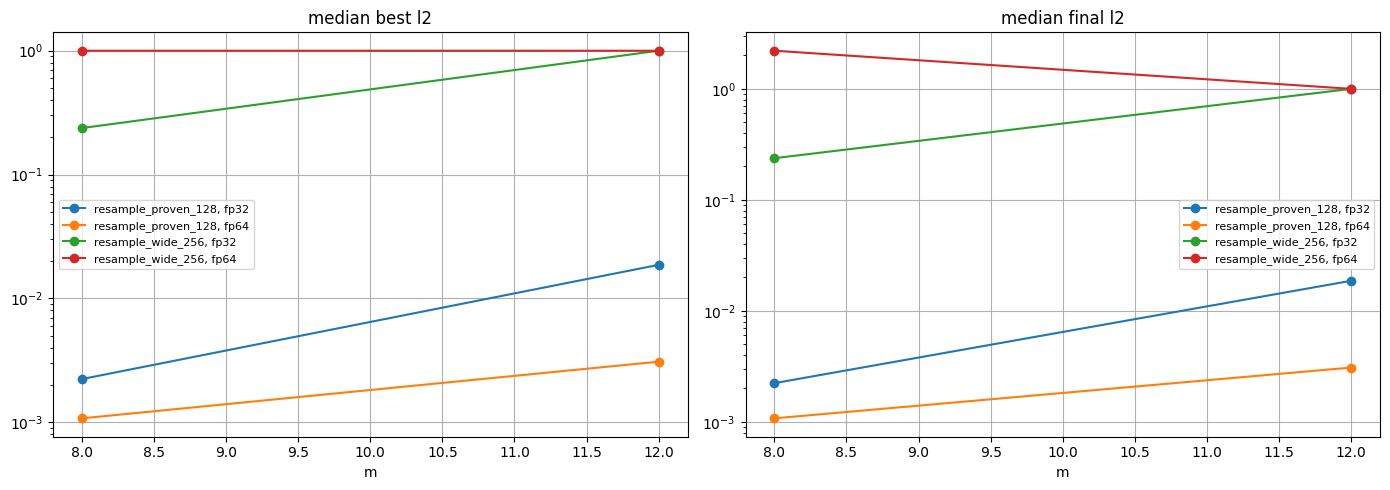

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for variant in grouped["variant"].unique():
    for dtype in dtype_values:
        cur = grouped[(grouped["variant"] == variant) & (grouped["dtype"] == dtype)].sort_values("m")
        if len(cur) == 0:
            continue
        label = f"{variant}, {dtype}"
        ax[0].plot(cur["m"], cur["best_l2_median"], marker="o", label=label)
        ax[1].plot(cur["m"], cur["final_l2_median"], marker="o", label=label)

ax[0].set_title("median best l2")
ax[1].set_title("median final l2")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
for a in ax:
    a.set_xlabel("m")
    a.grid(True)
    a.legend(fontsize=8)

fig.tight_layout()
plt.show()


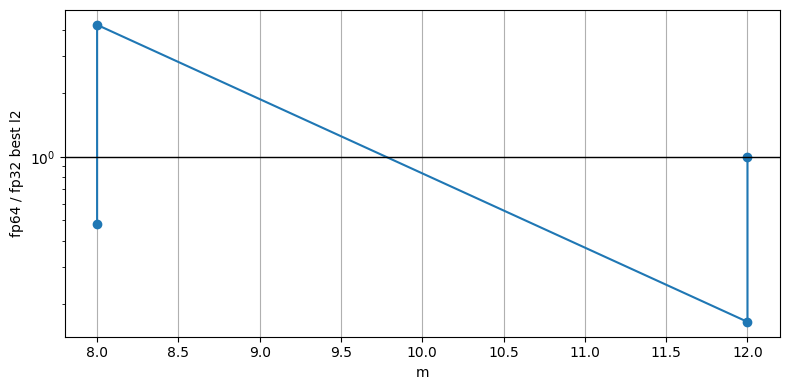

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
cur = best_pivot.sort_values("m")
ax.plot(cur["m"], cur["fp64_over_fp32"], marker="o")
ax.axhline(1.0, color="black", linewidth=1)
ax.set_xlabel("m")
ax.set_ylabel("fp64 / fp32 best l2")
ax.set_yscale("log")
ax.grid(True)
fig.tight_layout()
plt.show()


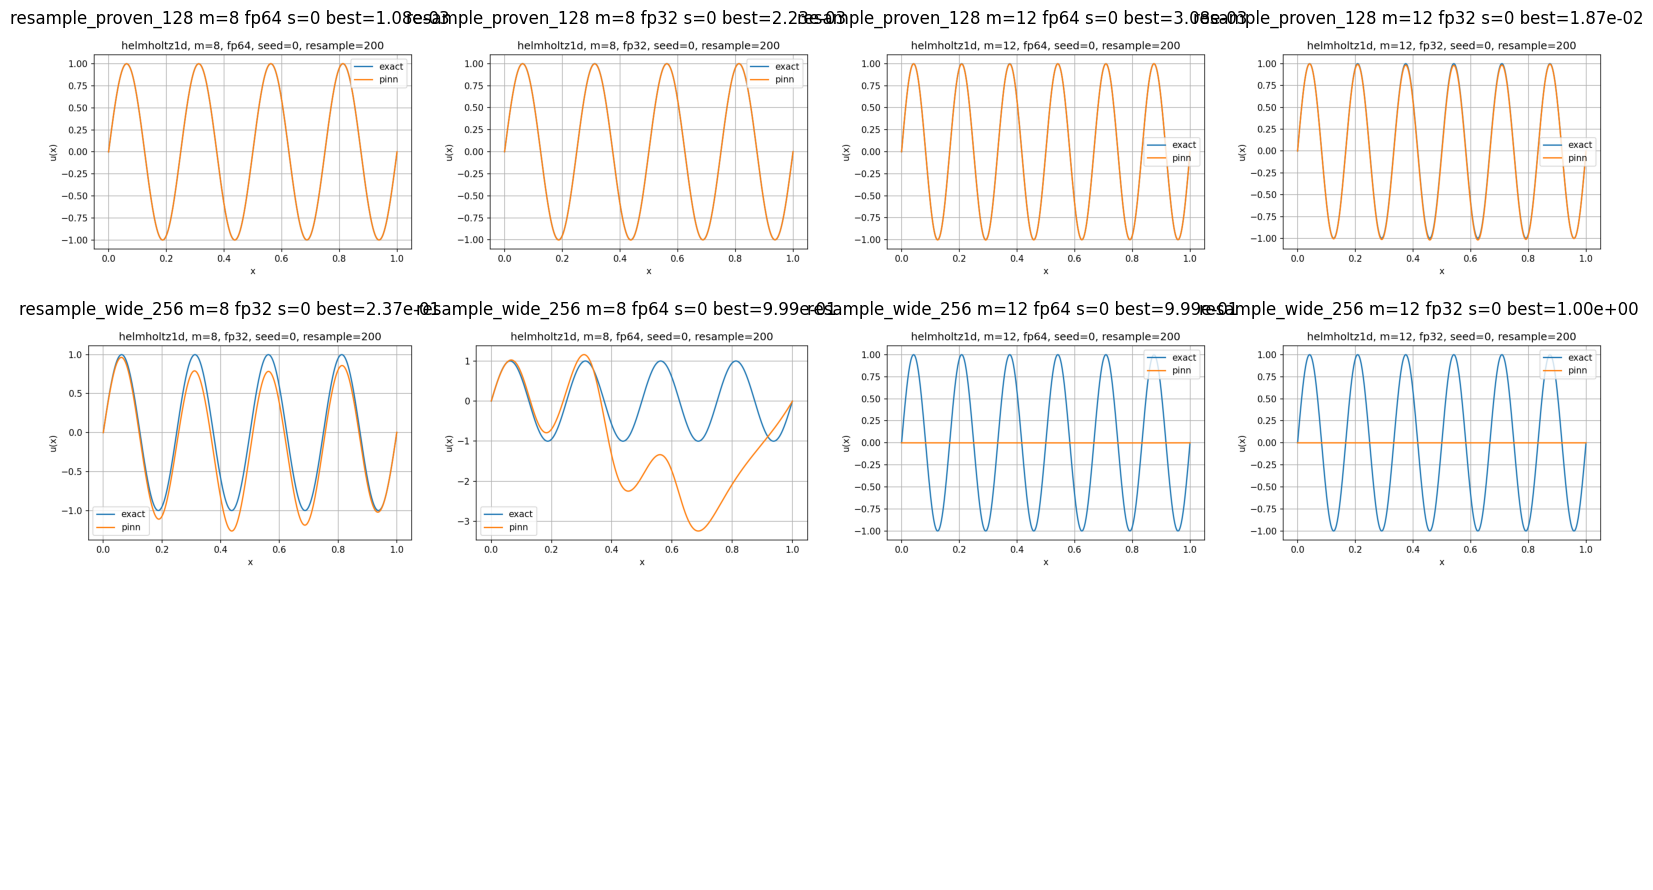

In [11]:
show = df.sort_values("best_l2_error").head(12)
rows = 3
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(16, 9))
ax = np.array(ax).reshape(rows, cols)

for k in range(rows * cols):
    r = k // cols
    c = k % cols
    ax[r, c].axis("off")
    if k >= len(show):
        continue
    row = show.iloc[k]
    p = Path(row["log_dir"]) / "solution_t1.png"
    ax[r, c].set_title(f"{row['variant']} m={row['m']} {row['dtype']} s={row['seed']} best={row['best_l2_error']:.2e}")
    if p.exists():
        img = plt.imread(p)
        ax[r, c].imshow(img)

fig.tight_layout()
plt.show()


In [12]:
bad = df.sort_values("best_l2_error", ascending=False).head(12)
bad[["variant", "m", "dtype", "seed", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "log_dir"]]


,variant,m,dtype,seed,final_l2_error,best_l2_error,best_step,l2_ratio,log_dir
6,resample_wide_256,12,fp32,0,1.000001,0.999639,2600,1.000361,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
7,resample_wide_256,12,fp64,0,1.000001,0.999259,4700,1.000743,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
3,resample_wide_256,8,fp64,0,2.205891,0.999107,4600,2.207862,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
2,resample_wide_256,8,fp32,0,0.237307,0.237307,9000,1.000000,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
4,resample_proven_128,12,fp32,0,0.018669,0.018669,11000,1.000000,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
5,resample_proven_128,12,fp64,0,0.003085,0.003085,11000,1.000000,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
0,resample_proven_128,8,fp32,0,0.002232,0.002232,10200,1.000000,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
1,resample_proven_128,8,fp64,0,0.001076,0.001076,10300,1.000000,results_exp_9_helmholtz1d_large_lbfgs/runs/exp...
